In [ ]:
# here we are creating a prompt chaining sequential workflow for writting and evaluating a written blog

In [10]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

In [11]:
# load model
load_dotenv()

model = ChatGroq(model="llama-3.1-8b-instant")

In [12]:
# create state
class BlogState(TypedDict):
    title: str
    outline: str
    blog_content: str
    score: float

In [13]:
# outline generation node
def generate_outline(state: BlogState) -> BlogState:
    # fetch title from state
    title = state['title']

    # generate prompt
    prompt = f"Generate a detailed outline for a blog on topic - {title}"

    # generate outline
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [14]:
# blog generation node
def generate_blog(state: BlogState) -> BlogState:
    # fetch outline and title
    outline = state['outline']
    title = state['title']

    # generate prompt
    prompt = f"write a detailed blog on topic {title} using the following outline \n\n {outline}"

    # write blog
    blog = model.invoke(prompt).content

    # update state
    state['blog_content'] = blog

    return state

In [15]:
# blog evaluation node
def eval_blog(state: BlogState) -> BlogState:
    # fetch blog, outline
    outline = state['outline']
    blog = state['blog_content']

    # generate prompt
    prompt = f"Rate the following blog from 0 to 10 based on how well it follows the given outline. Return only the integer score.\n\nOutline:\n{outline}\n\nBlog:\n{blog}"

    # evaluate the blog
    score = model.invoke(prompt).content

    # update state
    state['score'] = score

    return state

In [16]:
# define graph
graph = StateGraph(BlogState)

# create nodes
graph.add_node('generate_outline', generate_outline)
graph.add_node('generate_blog', generate_blog)
graph.add_node('eval_blog', eval_blog)

# create edges 
graph.add_edge(START, 'generate_outline')
graph.add_edge('generate_outline', 'generate_blog')
graph.add_edge('generate_blog','eval_blog')
graph.add_edge('eval_blog', END)

# compile graph
workflow = graph.compile()

In [17]:
# execute graph

initial_state = {"title": "Rise of Artificial Intelligence"}

last_state = workflow.invoke(initial_state)

In [18]:
print(last_state['outline'])

**Title:** "The Rise of Artificial Intelligence: A Comprehensive Guide to the Future of Technology"

**I. Introduction**

* Brief overview of Artificial Intelligence (AI)
* Importance of AI in modern technology
* Thesis statement: The rise of AI is transforming industries, revolutionizing how we live and work, and opening doors to new possibilities.

**II. History of AI**

* Early beginnings: 1950s-1970s
* Developments in the 1980s and 1990s
* AI resurgence in the 21st century
* Key milestones: IBM's Deep Blue, Google's AlphaGo, and other significant advancements

**III. Types of AI**

* **Narrow or Weak AI**: Designed for specific tasks
* **General or Strong AI**: Capable of reasoning and learning like humans
* **Superintelligence**: Far surpassing human intelligence
* **Hybrid AI**: Combining human and artificial intelligence

**IV. Applications of AI**

* **Healthcare**: Diagnosis, personalized medicine, and patient care
* **Finance**: Risk assessment, portfolio management, and cust

In [ ]:
print(last_state['blog_content'])   

**The Rise of Artificial Intelligence: A Comprehensive Guide to the Future of Technology**

**I. Introduction**

Artificial Intelligence (AI) has become an integral part of modern technology, transforming industries and revolutionizing how we live and work. AI refers to the development of computer systems that can perform tasks that would typically require human intelligence, such as learning, problem-solving, and decision-making. The importance of AI in modern technology cannot be overstated, as it has the potential to solve complex problems, increase efficiency, and enhance customer experiences.

The rise of AI is transforming industries, revolutionizing how we live and work, and opening doors to new possibilities. AI has the potential to automate tasks, improve decision-making, and enhance customer experiences, leading to increased productivity and competitiveness. In this comprehensive guide, we will explore the history of AI, types of AI, applications, benefits, challenges, and em

In [20]:
print(last_state['score'])

8


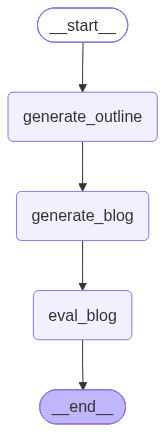

In [22]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())